<a href="https://colab.research.google.com/github/amalendukithu06-cyber/DSA/blob/main/UnSupervised_Learning_Case_Study.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [4]:
df = pd.read_csv("adult_dataset.csv")

In [5]:
df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40.0,NaN,<=50K
1,50.0,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13.0,United-States,<=50K
2,38.0,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40.0,United-States,<=50K
3,53.0,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40.0,United-States,<=50K
4,28.0,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40.0,Cuba,<=50K


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             46400 non-null  float64
 1   workclass       45480 non-null  object 
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  object 
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  object 
 6   occupation      45485 non-null  object 
 7   relationship    48842 non-null  object 
 8   race            48842 non-null  object 
 9   sex             48842 non-null  object 
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  46400 non-null  float64
 13  native-country  46137 non-null  object 
 14  income          48842 non-null  object 
dtypes: float64(2), int64(4), object(9)
memory usage: 5.6+ MB


In [7]:
df.shape

(48842, 15)

In [8]:
df = df.replace(" ?", np.nan)
df = df.replace("?", np.nan)

In [9]:
df.isnull().sum()

,0
age,2442
workclass,5125
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,5115
relationship,0
race,0
sex,0


In [10]:
cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_2455/719105301.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


In [11]:
num_cols = df.select_dtypes(include=["int64","float64"]).columns

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_2455/890633477.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [12]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

cat_cols = df.select_dtypes(include="object").columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39.0,6,77516,9,13,4,0,1,4,1,2174,0,40.0,38,0
1,50.0,5,83311,9,13,2,3,0,4,1,0,0,13.0,38,0
2,38.0,3,215646,11,9,0,5,1,4,1,0,0,40.0,38,0
3,53.0,3,234721,1,7,2,5,0,2,1,0,0,40.0,38,0
4,28.0,3,338409,9,13,2,9,5,2,0,0,0,40.0,4,0


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             48842 non-null  float64
 1   workclass       48842 non-null  int64  
 2   fnlwgt          48842 non-null  int64  
 3   education       48842 non-null  int64  
 4   education-num   48842 non-null  int64  
 5   marital-status  48842 non-null  int64  
 6   occupation      48842 non-null  int64  
 7   relationship    48842 non-null  int64  
 8   race            48842 non-null  int64  
 9   sex             48842 non-null  int64  
 10  capital-gain    48842 non-null  int64  
 11  capital-loss    48842 non-null  int64  
 12  hours-per-week  48842 non-null  float64
 13  native-country  48842 non-null  int64  
 14  income          48842 non-null  int64  
dtypes: float64(2), int64(13)
memory usage: 5.6 MB


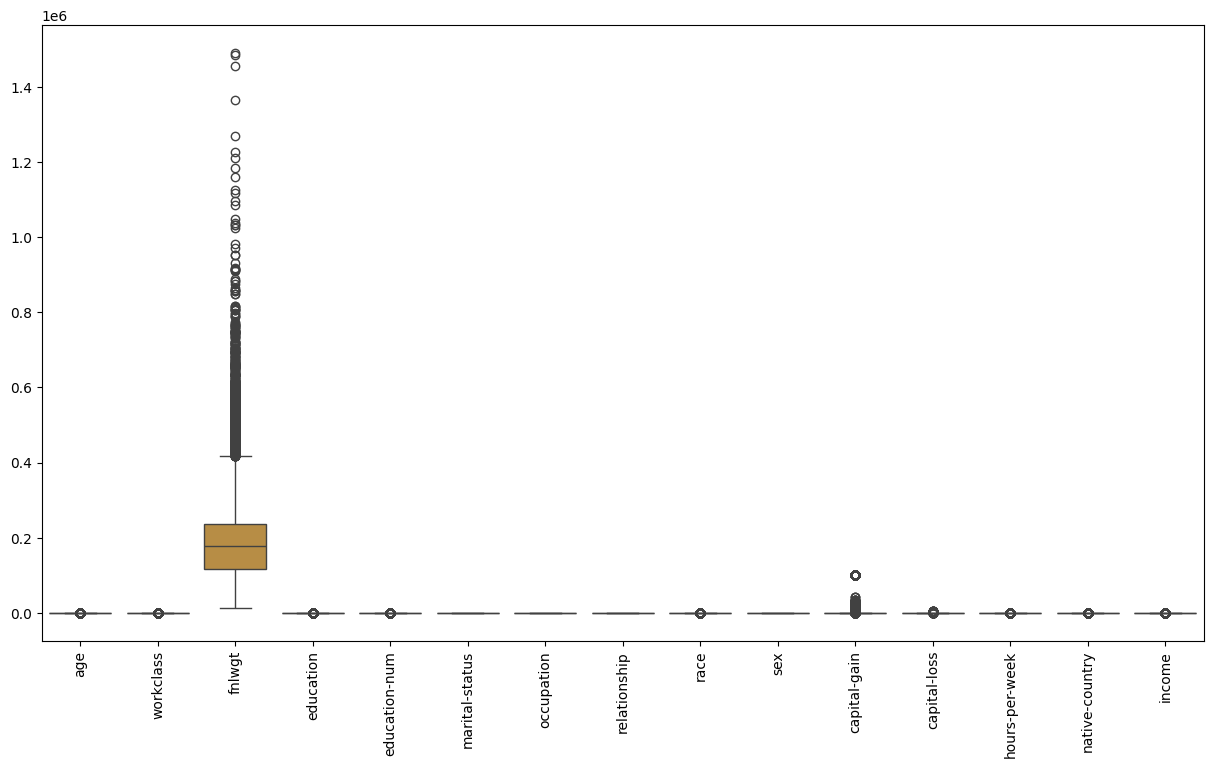

In [15]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [16]:
Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)

IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [17]:
df.shape

(15614, 15)

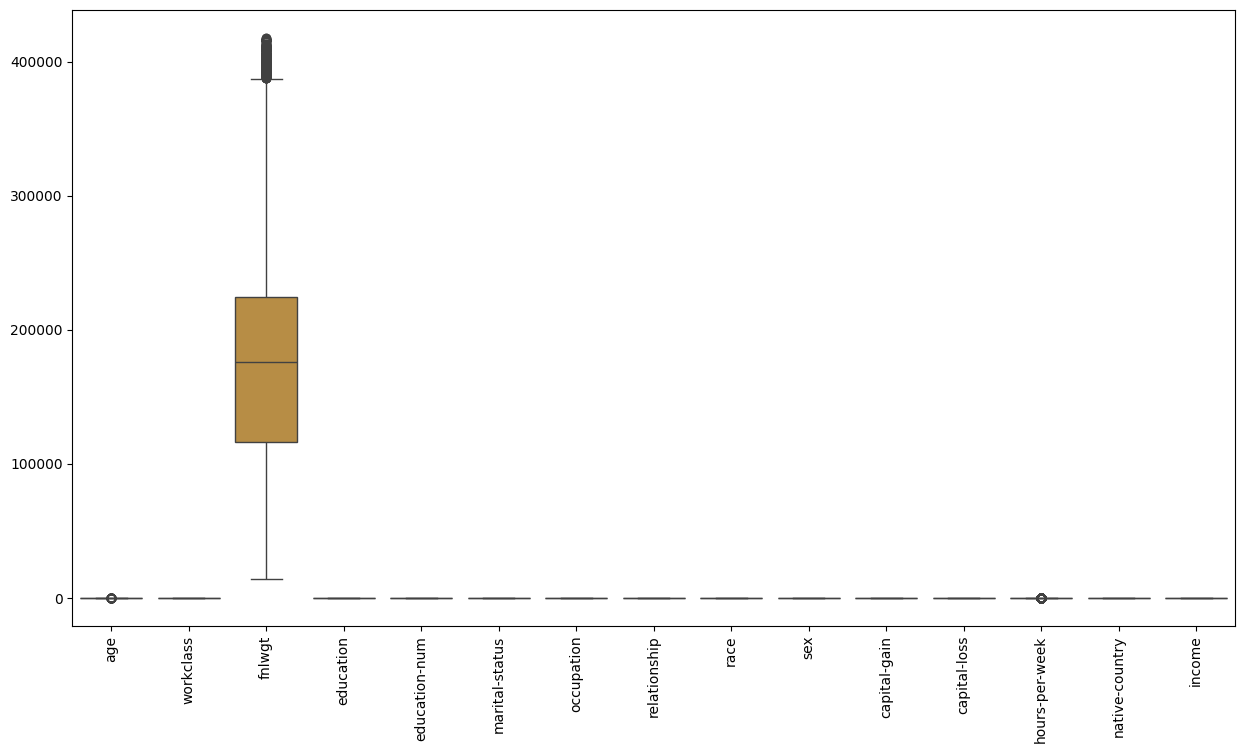

In [18]:
plt.figure(figsize=(15,8))
sns.boxplot(data=df)
plt.xticks(rotation=90)
plt.show()

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [20]:
scaled_df = pd.DataFrame(scaled_data, columns=df.columns)

scaled_df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,0.122599,0.0,0.440981,-0.13437,-0.721382,-1.658106,-0.239891,-0.279144,0.0,0.712548,0.0,0.0,-0.372671,0.0,-0.800194
1,0.036961,0.0,1.247438,0.26771,1.999178,-0.363687,-0.731190,2.319874,0.0,-1.403414,0.0,0.0,-0.372671,0.0,-0.800194
2,-0.391229,0.0,0.103803,-0.13437,-0.721382,0.930731,0.005758,1.670120,0.0,0.712548,0.0,0.0,-0.372671,0.0,-0.800194
3,1.920998,0.0,-0.806456,-0.13437,-0.721382,-1.658106,1.479655,1.670120,0.0,-1.403414,0.0,0.0,-0.372671,0.0,-0.800194
4,-1.504524,0.0,-0.112973,-0.13437,-0.721382,0.930731,-0.976839,1.020365,0.0,0.712548,0.0,0.0,-0.372671,0.0,-0.800194


In [21]:
scaled_df.shape

(15614, 15)

In [22]:
scaled_df.describe()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
count,1.561400e+04,15614.0,1.561400e+04,1.561400e+04,1.561400e+04,1.561400e+04,1.561400e+04,1.561400e+04,15614.0,1.561400e+04,15614.0,15614.0,1.561400e+04,15614.0,1.561400e+04
mean,-3.640542e-17,0.0,-1.037554e-16,1.865778e-16,-1.456217e-17,6.006894e-17,-8.737300e-17,7.281083e-18,0.0,4.732704e-17,0.0,0.0,1.638244e-16,0.0,-4.368650e-17
std,1.000032e+00,0.0,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,1.000032e+00,0.0,1.000032e+00,0.0,0.0,1.000032e+00,0.0,1.000032e+00
min,-1.675800e+00,0.0,-1.920704e+00,-2.144773e+00,-2.897831e+00,-1.658106e+00,-1.468138e+00,-9.288984e-01,0.0,-1.403414e+00,0.0,0.0,-2.202671e+00,0.0,-8.001941e-01
25%,-8.194191e-01,0.0,-7.253318e-01,-9.385312e-01,-7.213824e-01,-3.636873e-01,-9.768395e-01,-9.288984e-01,0.0,-1.403414e+00,0.0,0.0,-3.726705e-01,0.0,-8.001941e-01
50%,-4.867668e-02,0.0,-2.702867e-02,-1.343702e-01,-1.772703e-01,-3.636873e-01,5.758145e-03,-2.791439e-01,0.0,7.125482e-01,0.0,0.0,-3.726705e-01,0.0,-8.001941e-01
75%,6.364277e-01,0.0,5.449234e-01,1.473952e+00,9.109539e-01,9.307311e-01,7.427064e-01,1.020365e+00,0.0,7.125482e-01,0.0,0.0,-3.726705e-01,0.0,5.437051e-01
max,3.291207e+00,0.0,2.804362e+00,1.473952e+00,3.087402e+00,2.225150e+00,1.725304e+00,2.319874e+00,0.0,7.125482e-01,0.0,0.0,2.764472e+00,0.0,1.887604e+00


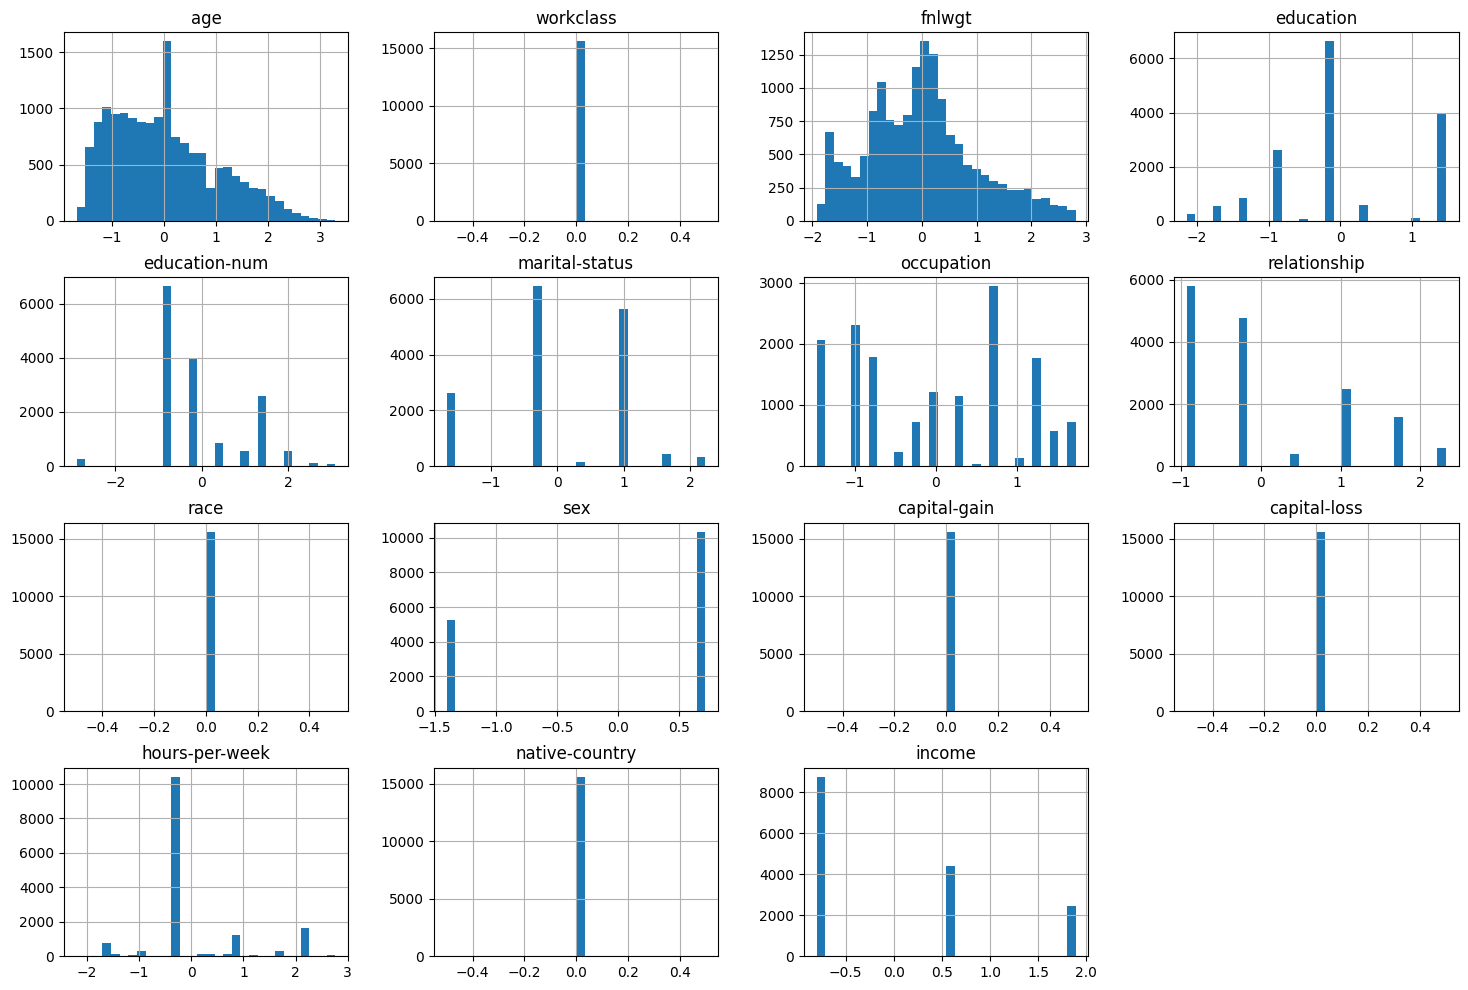

In [23]:
scaled_df.hist(figsize=(18,12), bins=30)
plt.show()

In [24]:
corr = scaled_df.corr()

corr

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
age,1.000000,NaN,-0.060694,-0.056107,0.018844,-0.321107,-0.010617,-0.223244,NaN,0.048007,NaN,NaN,0.060773,NaN,0.181866
workclass,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
fnlwgt,-0.060694,NaN,1.000000,0.018062,0.000590,0.035740,-0.011039,0.008898,NaN,0.014349,NaN,NaN,-0.009124,NaN,-0.000086
education,-0.056107,NaN,0.018062,1.000000,-0.199595,0.021230,-0.020690,0.062566,NaN,-0.027781,NaN,NaN,-0.034794,NaN,-0.038689
education-num,0.018844,NaN,0.000590,-0.199595,1.000000,0.032307,0.085545,-0.066534,NaN,-0.013196,NaN,NaN,0.110692,NaN,0.198055
marital-status,-0.321107,NaN,0.035740,0.021230,0.032307,1.000000,0.031714,0.137560,NaN,-0.052218,NaN,NaN,-0.086620,NaN,-0.121676
occupation,-0.010617,NaN,-0.011039,-0.020690,0.085545,0.031714,1.000000,-0.060616,NaN,0.078921,NaN,NaN,0.046253,NaN,0.030973
relationship,-0.223244,NaN,0.008898,0.062566,-0.066534,0.137560,-0.060616,1.000000,NaN,-0.521016,NaN,NaN,-0.182934,NaN,-0.173205
race,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sex,0.048007,NaN,0.014349,-0.027781,-0.013196,-0.052218,0.078921,-0.521016,NaN,1.000000,NaN,NaN,0.179420,NaN,0.145470


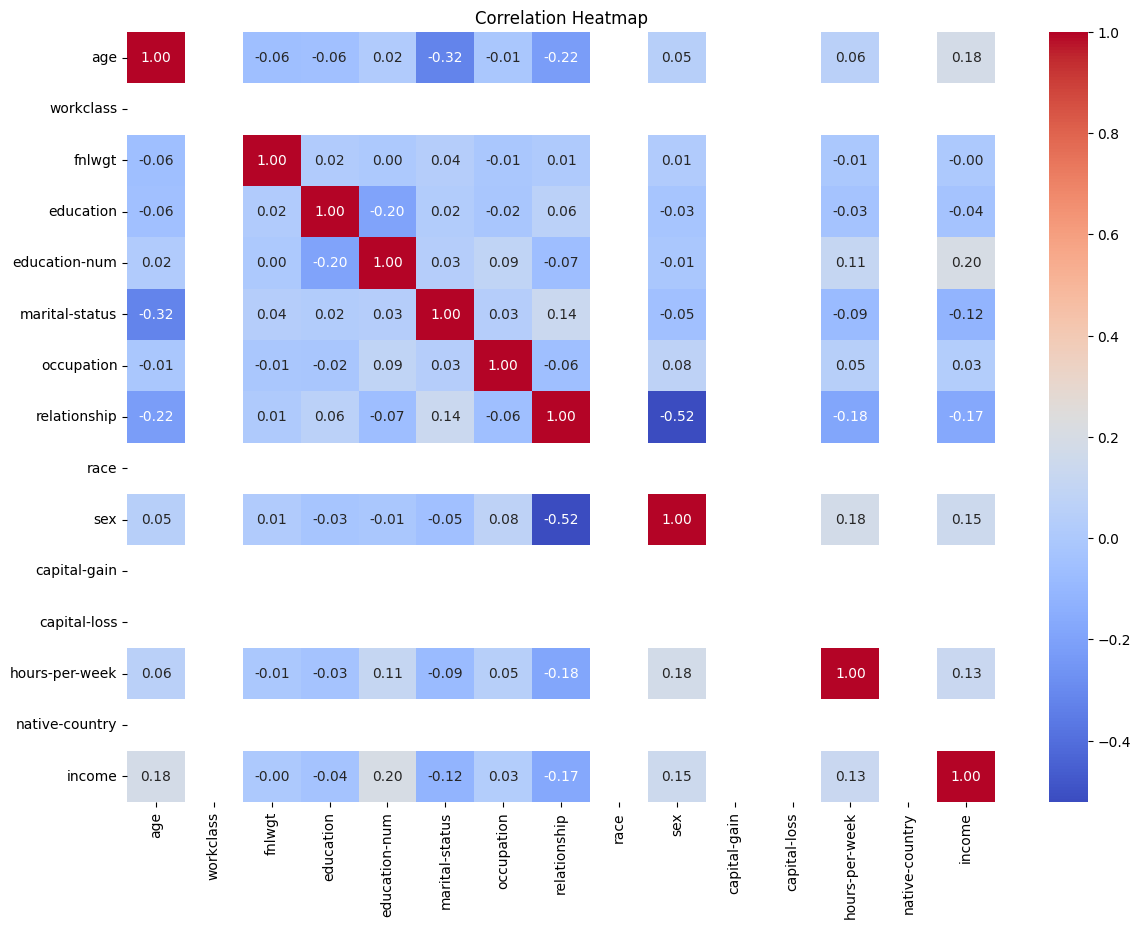

In [25]:
plt.figure(figsize=(14,10))

sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

In [26]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_df)

In [27]:
pca_df = pd.DataFrame(pca_data, columns=["PC1","PC2"])

pca_df.head()

,PC1,PC2
0,-0.434964,-1.271424
1,1.964336,0.251912
2,1.501999,0.306541
3,0.700371,-2.022017
4,1.642752,0.467476


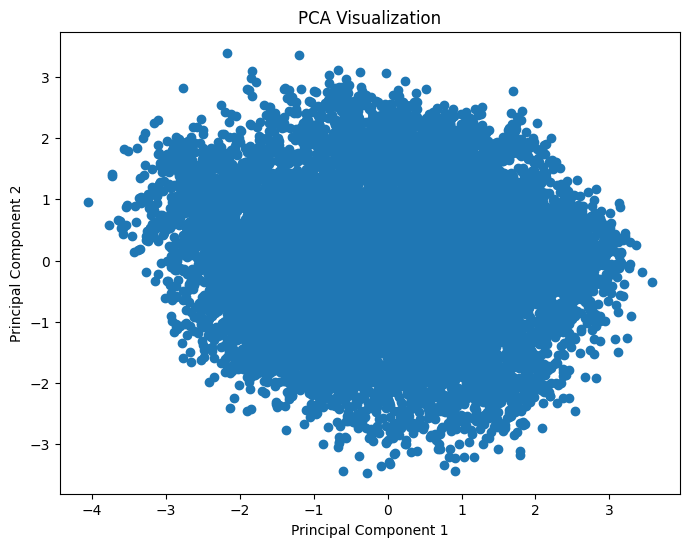

In [28]:
plt.figure(figsize=(8,6))

plt.scatter(pca_df["PC1"], pca_df["PC2"])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA Visualization")

plt.show()

In [29]:
print(pca.explained_variance_ratio_)

[0.19473268 0.12638313]


In [30]:
from sklearn.cluster import KMeans

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

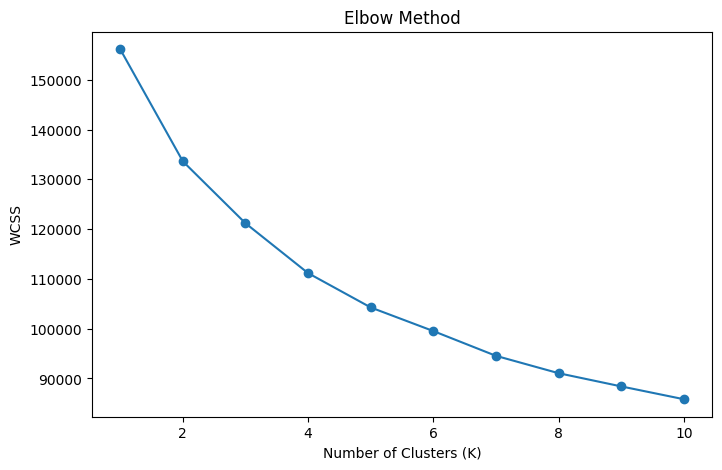

In [31]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")

plt.show()

In [32]:
from sklearn.metrics import silhouette_score

for k in range(2,11):
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, labels)

    print("K =", k, "Silhouette Score =", round(score,3))

K = 2 Silhouette Score = 0.144
K = 3 Silhouette Score = 0.151
K = 4 Silhouette Score = 0.144
K = 5 Silhouette Score = 0.146
K = 6 Silhouette Score = 0.136
K = 7 Silhouette Score = 0.135
K = 8 Silhouette Score = 0.134
K = 9 Silhouette Score = 0.133
K = 10 Silhouette Score = 0.135


In [33]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

clusters = kmeans.fit_predict(scaled_df)

In [34]:
df["Cluster"] = clusters

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,Cluster
2,38.0,3,215646,11,9,0,5,1,4,1,0,0,40.0,38,0,2
5,37.0,3,284582,12,14,2,3,5,4,0,0,0,40.0,38,0,0
17,32.0,3,186824,11,9,4,6,4,4,1,0,0,40.0,38,0,1
24,59.0,3,109015,11,9,0,12,4,4,0,0,0,40.0,38,0,0
26,19.0,3,168294,11,9,4,2,3,4,1,0,0,40.0,38,0,1


In [35]:
df["Cluster"].value_counts()

,count
Cluster,
2,7059
1,6010
0,2545


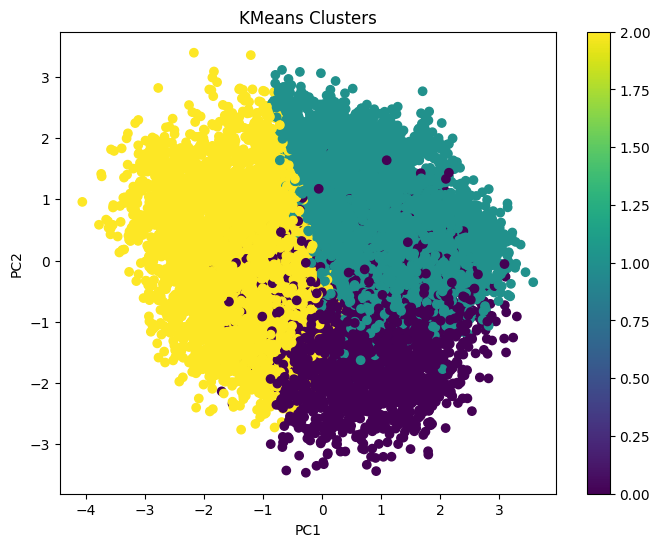

In [36]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=clusters,
    cmap="viridis"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Clusters")

plt.colorbar()

plt.show()

In [37]:
kmeans.cluster_centers_

array([[ 0.36484237,  0.        , -0.05924801,  0.03578333, -0.09346206,
        -1.29470223, -0.18892745,  1.15133718,  0.        , -1.18225624,
         0.        ,  0.        , -0.19835055,  0.        , -0.07095058],
       [-0.59688844,  0.        ,  0.06736415,  0.07182151, -0.01367452,
         1.02625102,  0.00207954,  0.45547867,  0.        , -0.32853323,
         0.        ,  0.        , -0.2469586 ,  0.        , -0.35230226],
       [ 0.37665047,  0.        , -0.03599268, -0.07404957,  0.04533855,
        -0.40696295,  0.06634401, -0.80288709,  0.        ,  0.70595365,
         0.        ,  0.        ,  0.28177126,  0.        ,  0.32552852]])

In [38]:
cluster_profile = df.groupby("Cluster").mean()

cluster_profile

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
Cluster,,,,,,,,,,,,,,,
0,40.828684,3.0,172886.388212,11.423183,10.154028,0.561493,5.207466,3.201572,4.0,0.104519,0.0,0.0,40.666798,38.0,0.542633
1,29.598502,3.0,183709.204326,11.512812,10.300666,4.147587,5.985025,2.130616,4.0,0.507987,0.0,0.0,40.480865,38.0,0.333278
2,40.966568,3.0,174874.255560,11.150021,10.409123,1.933135,6.246636,0.193937,4.0,0.996883,0.0,0.0,42.503329,38.0,0.837654


In [39]:
from sklearn.cluster import AgglomerativeClustering

In [40]:
agg = AgglomerativeClustering(n_clusters=3)

agg_clusters = agg.fit_predict(scaled_df)

In [41]:
df["Agg_Cluster"] = agg_clusters

df.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,Cluster,Agg_Cluster
2,38.0,3,215646,11,9,0,5,1,4,1,0,0,40.0,38,0,2,1
5,37.0,3,284582,12,14,2,3,5,4,0,0,0,40.0,38,0,0,0
17,32.0,3,186824,11,9,4,6,4,4,1,0,0,40.0,38,0,1,0
24,59.0,3,109015,11,9,0,12,4,4,0,0,0,40.0,38,0,0,0
26,19.0,3,168294,11,9,4,2,3,4,1,0,0,40.0,38,0,1,0


In [42]:
df["Agg_Cluster"].value_counts()

,count
Agg_Cluster,
0,7213
1,5412
2,2989


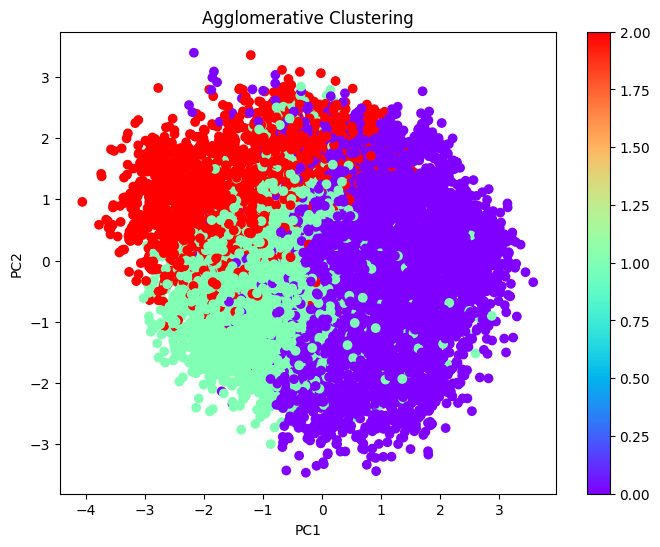

In [43]:
plt.figure(figsize=(8,6))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=agg_clusters,
    cmap="rainbow"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Agglomerative Clustering")

plt.colorbar()

plt.show()

In [44]:
from scipy.cluster.hierarchy import linkage, dendrogram
linked = linkage(scaled_df, method="ward")

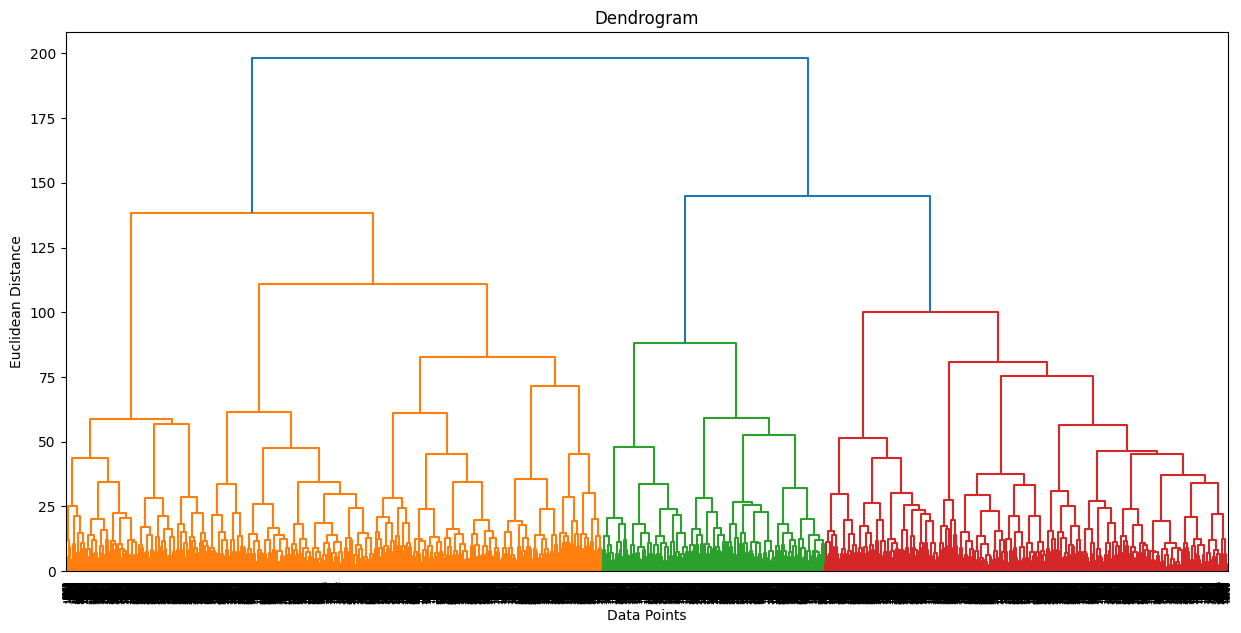

In [45]:
plt.figure(figsize=(15,7))

dendrogram(linked)

plt.title("Dendrogram")

plt.xlabel("Data Points")

plt.ylabel("Euclidean Distance")

plt.show()

In [46]:
df.groupby("Agg_Cluster").mean()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,Cluster
Agg_Cluster,,,,,,,,,,,,,,,,
0,33.600860,3.0,178886.662692,11.787190,10.150146,3.063219,5.626230,2.454873,4.0,0.280743,0.0,0.0,40.255372,38.0,0.422432,0.707195
1,39.687546,3.0,181384.429970,11.947154,9.203991,1.933851,6.111050,0.474316,4.0,0.987066,0.0,0.0,42.343681,38.0,0.627494,1.821877
2,38.081967,3.0,169475.916025,9.131148,12.780863,2.489461,6.578454,0.685179,4.0,1.000000,0.0,0.0,42.586818,38.0,0.954834,1.728672


In [47]:
df.groupby("Agg_Cluster").size()

,0
Agg_Cluster,
0,7213
1,5412
2,2989


In [48]:
pd.crosstab(df["Cluster"], df["income"])

income,0,1,2
Cluster,,,
0,1463,783,299
1,4069,1879,62
2,3227,1751,2081
